In [1]:
from flow_network import FlowNetwork
from contrastive_optimizer import ContrastiveOptimizer
import numpy as np
import matplotlib.pyplot as plt

import os

%load_ext autoreload
%autoreload 2

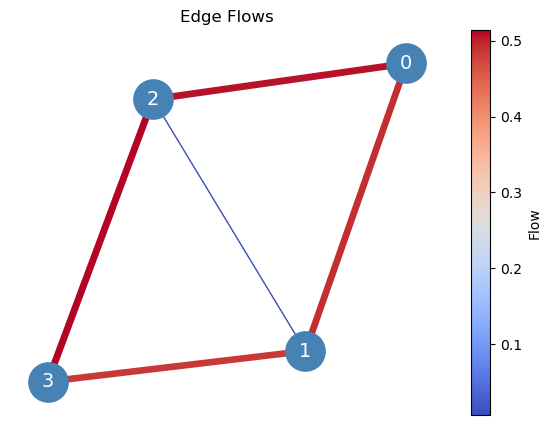

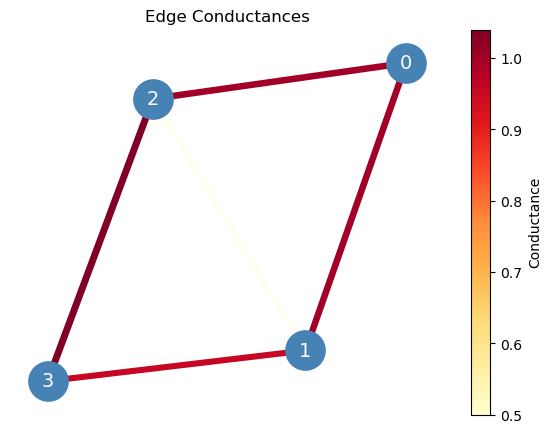

 idx      edge        flow   conductance
----------------------------------------
   0  (0,1):      0.4930        1.0000
   1  (0,2):      0.5070        1.0000
   2  (1,2):      0.0070        0.5000
   3  (1,3):      0.4860        0.9565
   4  (2,3):      0.5140        1.0400


In [2]:

# set up a Murray network: such that obbays a_i^3 = a_j^3 + a_k^3 for all i,j,k in a jubction
# such one is 
# 0,1: 1
# 0,2: 1
# 2,1: 1/2
# 1,3: (1+eps)^(1/3)
# 2,3: (1-eps)^(1/3)

eps = 2**-3  # = 0.125

W = np.array([
    [0,           1,           1,                    0             ],
    [1,           0,           1/2,                  (1-eps)**(1/3)],
    [1,           1/2,         0,                    (1+eps)**(1/3)],
    [0,           (1-eps)**(1/3), (1+eps)**(1/3),   0             ],
], dtype=float)

net = FlowNetwork(W)


Q_in = np.array([1., 0., 0., -1.])  # source and sink
target_edge = (1, 2)  # the edge we want to control the flow through
desired_flow_target = 0.1  # the desired flow through the target edge
learning_rate = 1  # learning rate for the optimization
clamp_strength = 0.1  # strength of the nudge applied to the network
loss_tol = 1e-5  # tolerance for the loss function

net.plot_flows(Q_in=Q_in)  # source and sink
net.plot_conductances()
net.print_edges(Q_in=Q_in)  # source and sink


In [3]:
# First, check the same architecture with PD contrastive optimization. This should converge to the same solution as the shear rate contrastive optimization, since the two loss functions are equivalent for this network architecture.
update_func1 = 'PD'  # update function for the optimization
max_iter = 100_000_000  # maximum number of iterations for the optimization
net_pd = FlowNetwork(W)  # make a copy of the network for the PD optimization


opt = ContrastiveOptimizer(net_pd, Q_in, target_edge=target_edge, 
                            desired_flow_target=desired_flow_target,
                           learning_rate=learning_rate, 
                           clamp_strength=clamp_strength, 
                           loss_tol=loss_tol, 
                           update_func=update_func1)
                           
opt.run(max_iter=max_iter, log_every=100)  # run the optimization


# # Sound a beep when the optimization is done
# duration = 1  # seconds
# freq = 440  # Hz
# os.system('play -nq -t alsa synth {} sine {}'.format(duration, freq))


AttributeError: 'FlowNetwork' object has no attribute 'nodes'

In [68]:

opt.plot_history(title="Power Dissipation Optimization", label_fontsize=18)



AttributeError: 'ContrastiveOptimizer' object has no attribute 'plot_history'

In [ ]:
update_func2 = 'SR_global_shear'  # update function for the optimization

net_sr_global = FlowNetwork(W)  # make a copy of the network for the shear rate optimization

opt_sr_global = ContrastiveOptimizer(net_sr_global, Q_in, target_edge=target_edge, 
                            desired_flow_target=desired_flow_target,
                           learning_rate=learning_rate, 
                           clamp_strength=clamp_strength, 
                           loss_tol=loss_tol, 
                           update_func=update_func2)

opt_sr_global.run(max_iter=100_000_000, log_every=100)





Initial flow on (1, 2): 0.0070  |  target: 0.1  |  loss: 0.004326

=== Optimization start ===
Iter     100  |  flow: 0.01141  |  loss: 0.003924
Iter     200  |  flow: 0.01535  |  loss: 0.003583
Iter     300  |  flow: 0.01889  |  loss: 0.003290
Iter     400  |  flow: 0.02208  |  loss: 0.003036
Iter     500  |  flow: 0.02498  |  loss: 0.002814
Iter     600  |  flow: 0.02763  |  loss: 0.002618
Iter     700  |  flow: 0.03007  |  loss: 0.002445
Iter     800  |  flow: 0.03231  |  loss: 0.002291
Iter     900  |  flow: 0.03439  |  loss: 0.002152
Iter    1000  |  flow: 0.03632  |  loss: 0.002027
Iter    1100  |  flow: 0.03812  |  loss: 0.001914
Iter    1200  |  flow: 0.03980  |  loss: 0.001812
Iter    1300  |  flow: 0.04138  |  loss: 0.001718
Iter    1400  |  flow: 0.04286  |  loss: 0.001632
Iter    1500  |  flow: 0.04426  |  loss: 0.001554
Iter    1600  |  flow: 0.04557  |  loss: 0.001481
Iter    1700  |  flow: 0.04682  |  loss: 0.001414
Iter    1800  |  flow: 0.04800  |  loss: 0.001352
Iter  

sh: play: command not found


32512

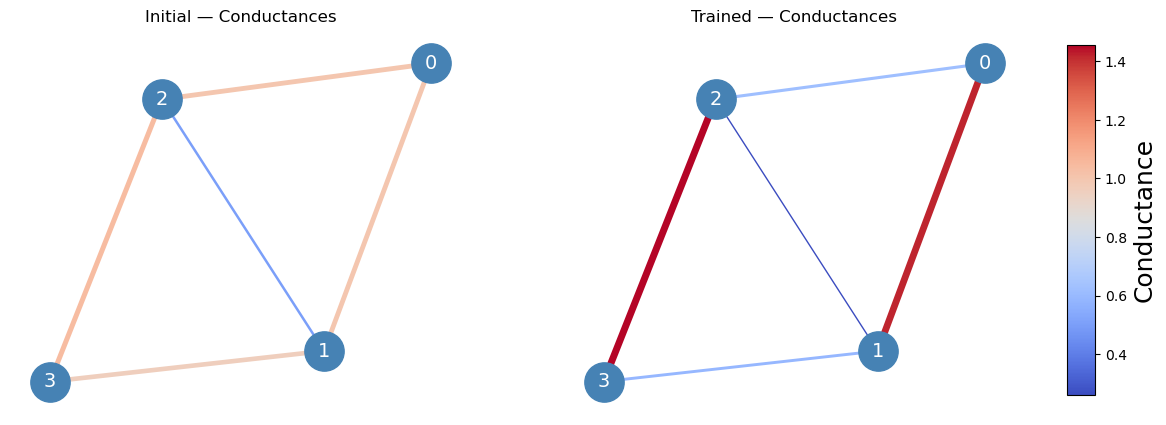

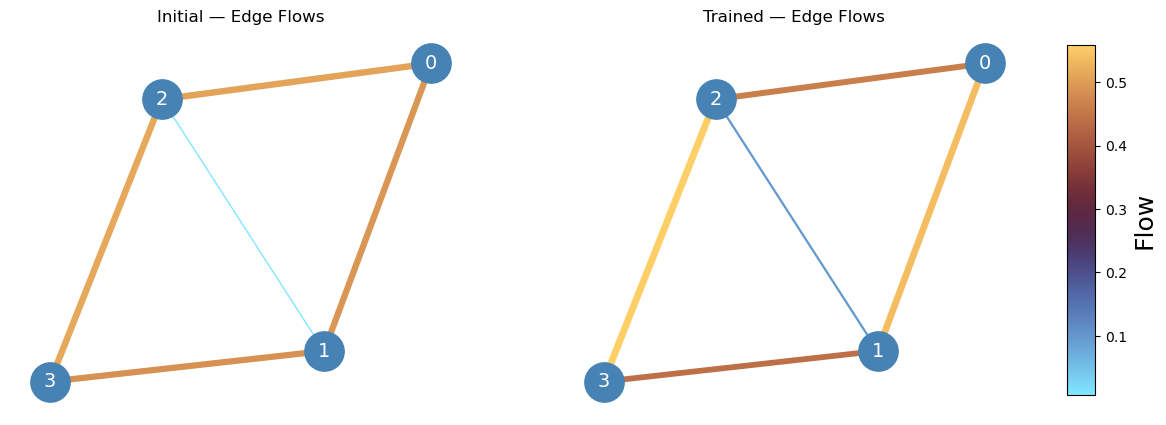

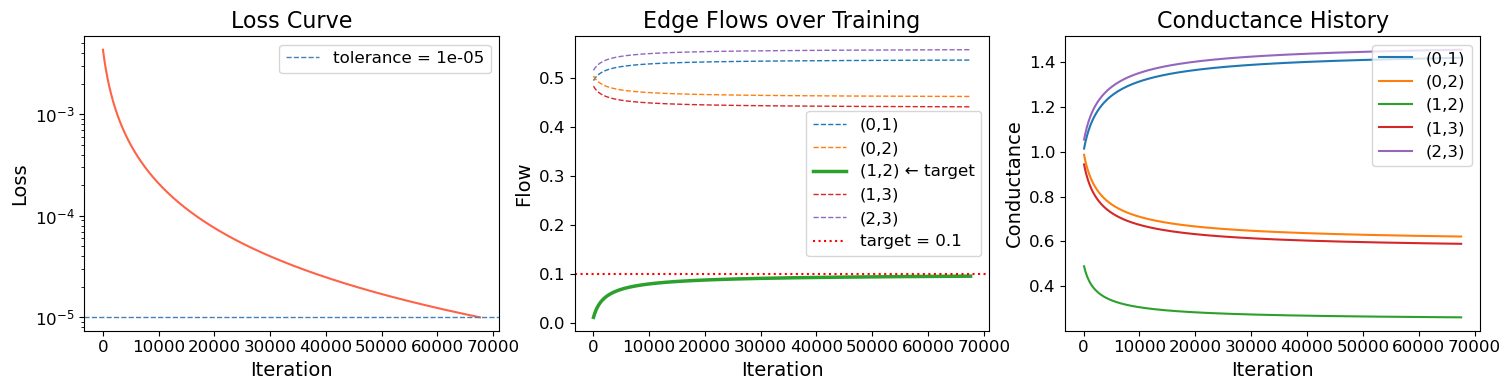

In [60]:
opt_sr_global.plot_results()


In [61]:
update_func3 = 'SR'  # update function for the optimization

net_sr = FlowNetwork(W)  # make a copy of the network for the shear rate optimization

opt_sr = ContrastiveOptimizer(net_sr, Q_in, target_edge=target_edge, 
                            desired_flow_target=desired_flow_target,
                           learning_rate=learning_rate, 
                           clamp_strength=clamp_strength, 
                           loss_tol=loss_tol, 
                           update_func=update_func3)

opt_sr.run(max_iter=100_000_000, log_every=100)

# Sound a beep when the optimization is done
duration = 1  # seconds
freq = 440  # Hz
os.system('play -nq -t alsa synth {} sine {}'.format(duration, freq))


Initial flow on (1, 2): 0.0070  |  target: 0.1  |  loss: 0.004326

=== Optimization start ===
Iter     100  |  flow: 0.01141  |  loss: 0.003924
Iter     200  |  flow: 0.01535  |  loss: 0.003583
Iter     300  |  flow: 0.01889  |  loss: 0.003290
Iter     400  |  flow: 0.02208  |  loss: 0.003036
Iter     500  |  flow: 0.02498  |  loss: 0.002814
Iter     600  |  flow: 0.02763  |  loss: 0.002618
Iter     700  |  flow: 0.03007  |  loss: 0.002445
Iter     800  |  flow: 0.03231  |  loss: 0.002291
Iter     900  |  flow: 0.03439  |  loss: 0.002152
Iter    1000  |  flow: 0.03632  |  loss: 0.002027
Iter    1100  |  flow: 0.03812  |  loss: 0.001914
Iter    1200  |  flow: 0.03980  |  loss: 0.001812
Iter    1300  |  flow: 0.04138  |  loss: 0.001718
Iter    1400  |  flow: 0.04286  |  loss: 0.001632
Iter    1500  |  flow: 0.04426  |  loss: 0.001554
Iter    1600  |  flow: 0.04557  |  loss: 0.001481
Iter    1700  |  flow: 0.04682  |  loss: 0.001414
Iter    1800  |  flow: 0.04800  |  loss: 0.001352
Iter  

sh: play: command not found


32512

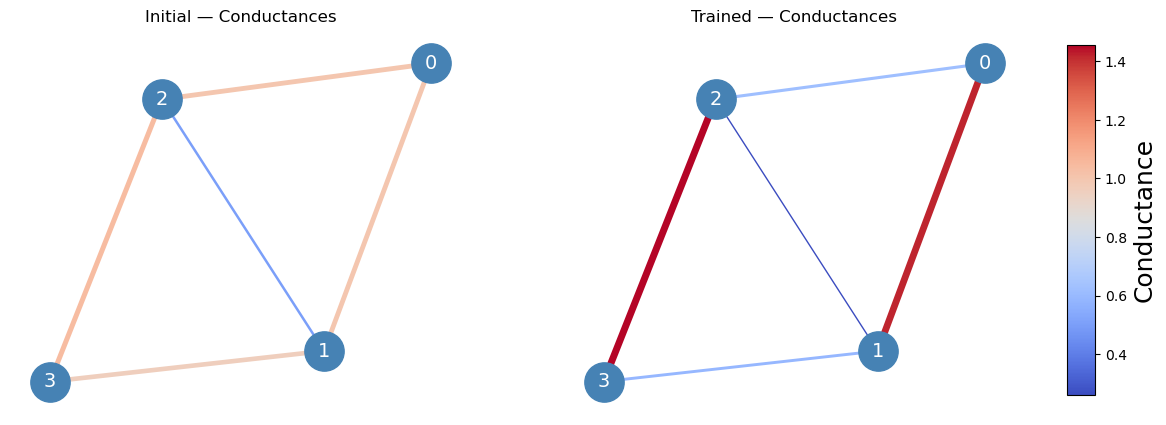

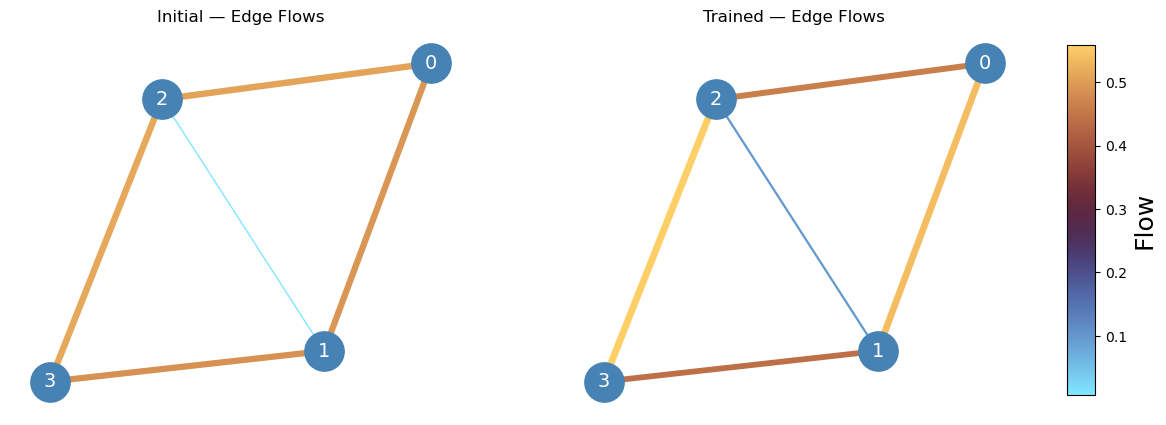

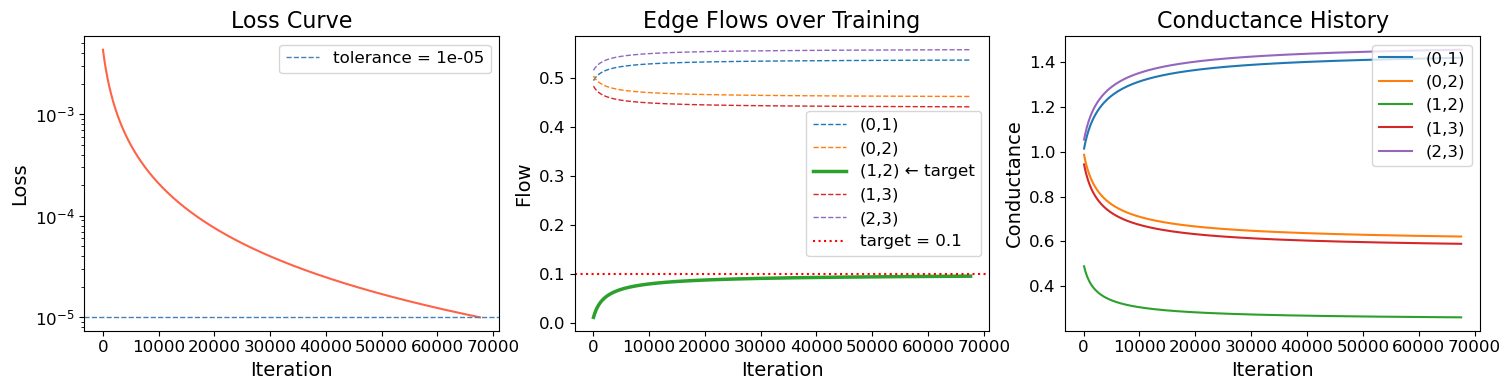

In [62]:

opt_sr.plot_results()

In [7]:
import contrastive_optimizer as co
print(co.__file__)

import os
print(os.getcwd())  # does this match where contrastive_optimizer.py actually lives?

/Users/mayagattharari/Documents/projects/simulation-project/flow_networks/contrastive_optimizer.py
/Users/mayagattharari/Documents/projects/simulation-project/flow_networks


In [8]:
import sys
print(sys.path)  # is your project directory in here, and is it first?

['/opt/miniconda3/envs/flow_networks/lib/python314.zip', '/opt/miniconda3/envs/flow_networks/lib/python3.14', '/opt/miniconda3/envs/flow_networks/lib/python3.14/lib-dynload', '', '/opt/miniconda3/envs/flow_networks/lib/python3.14/site-packages']
